In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df = pd.read_excel('card_transactions_dataset.xlsx')
df.head()

,Transaction_ID,Customer_ID,Card_Type,Masked_Card_Number,Transaction_Date,Transaction_Amount,Merchant_Category,Transaction_Channel,City,State,Risk_Flag,Is_Fraud
0,TXN_IND_00001,CUST_IN_4859,Credit Card,**** **** **** 6863,2025-05-14 13:00:00,39898.21,Travel,POS,Mumbai,Maharashtra,Low,0
1,TXN_IND_00002,CUST_IN_4311,Credit Card,**** **** **** 3482,2025-04-21 07:00:00,61812.70,Groceries,Online,Bhubaneswar,Odisha,Low,0
2,TXN_IND_00003,CUST_IN_2067,Credit Card,**** **** **** 2671,2025-07-25 21:00:00,5540.99,Electronics,Online,Nagpur,Maharashtra,Medium,0
3,TXN_IND_00004,CUST_IN_4655,Credit Card,**** **** **** 1733,2026-02-02 07:00:00,71851.13,Electronics,POS,Noida,Uttar Pradesh,Medium,0
4,TXN_IND_00005,CUST_IN_2072,Debit Card,**** **** **** 6010,2025-09-10 11:00:00,124607.80,Groceries,Online,Delhi,Delhi,Medium,0


In [3]:
df.shape

(1000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction_ID       1000 non-null   object        
 1   Customer_ID          1000 non-null   object        
 2   Card_Type            1000 non-null   object        
 3   Masked_Card_Number   1000 non-null   object        
 4   Transaction_Date     1000 non-null   datetime64[ns]
 5   Transaction_Amount   1000 non-null   float64       
 6   Merchant_Category    1000 non-null   object        
 7   Transaction_Channel  1000 non-null   object        
 8   City                 1000 non-null   object        
 9   State                1000 non-null   object        
 10  Risk_Flag            1000 non-null   object        
 11  Is_Fraud             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 93.9+ KB


In [5]:
df.describe()

,Transaction_Date,Transaction_Amount,Is_Fraud
count,1000,1000.000000,1000.000000
mean,2025-08-04 07:02:45.600000,74861.345650,0.060000
min,2025-01-01 03:00:00,1047.580000,0.000000
25%,2025-04-21 06:45:00,38356.385000,0.000000
50%,2025-08-07 17:00:00,73200.495000,0.000000
75%,2025-11-18 16:15:00,111719.215000,0.000000
max,2026-02-24 19:00:00,149998.500000,1.000000
std,NaN,42513.604127,0.237606


In [6]:
df['Is_Fraud'].value_counts()

Is_Fraud
0    940
1     60
Name: count, dtype: int64

In [7]:
print(df['City'].value_counts().head(5))

City
Jaipur        66
Guwahati      66
Chandigarh    63
Chennai       62
Kolkata       61
Name: count, dtype: int64


In [8]:
print(df.columns.tolist())

['Transaction_ID', 'Customer_ID', 'Card_Type', 'Masked_Card_Number', 'Transaction_Date', 'Transaction_Amount', 'Merchant_Category', 'Transaction_Channel', 'City', 'State', 'Risk_Flag', 'Is_Fraud']


In [9]:
# 1. Identify and convert the date column to datetime objects
date_cols = [col for col in df.columns if 'date' in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

if len(date_cols) > 0:
    target_date_col = date_cols[0]
    
    df['Transaction_Hour'] = df[target_date_col].dt.hour
    

    df['Transaction_Day'] = df[target_date_col].dt.dayofweek
    
    df['Late_Night_Risk'] = df['Transaction_Hour'].apply(lambda x: 1 if x >= 23 or x <= 5 else 0)
    
    df['Weekend_Flag'] = df['Transaction_Day'].apply(lambda x: 1 if x >= 4 else 0)

In [10]:
if 'Transaction_Amount' in df.columns:
    threshold = df['Transaction_Amount'].quantile(0.95)
    df['High_Amount_Flag'] = df['Transaction_Amount'].apply(lambda x: 1 if x > threshold else 0)

print("\nRisk Engineered Data Preview:")
print(df[['Transaction_ID', 'Transaction_Hour', 'Late_Night_Risk', 'High_Amount_Flag']].head(10))


Risk Engineered Data Preview:
  Transaction_ID  Transaction_Hour  Late_Night_Risk  High_Amount_Flag
0  TXN_IND_00001                13                0                 0
1  TXN_IND_00002                 7                0                 0
2  TXN_IND_00003                21                0                 0
3  TXN_IND_00004                 7                0                 0
4  TXN_IND_00005                11                0                 0
5  TXN_IND_00006                 8                0                 0
6  TXN_IND_00007                 7                0                 0
7  TXN_IND_00008                22                0                 0
8  TXN_IND_00009                19                0                 0
9  TXN_IND_00010                20                0                 0


In [11]:
df.info


<bound method DataFrame.info of     Transaction_ID   Customer_ID    Card_Type   Masked_Card_Number  \
0    TXN_IND_00001  CUST_IN_4859  Credit Card  **** **** **** 6863   
1    TXN_IND_00002  CUST_IN_4311  Credit Card  **** **** **** 3482   
2    TXN_IND_00003  CUST_IN_2067  Credit Card  **** **** **** 2671   
3    TXN_IND_00004  CUST_IN_4655  Credit Card  **** **** **** 1733   
4    TXN_IND_00005  CUST_IN_2072   Debit Card  **** **** **** 6010   
..             ...           ...          ...                  ...   
995  TXN_IND_00996  CUST_IN_2800  Credit Card  **** **** **** 7216   
996  TXN_IND_00997  CUST_IN_2342  Credit Card  **** **** **** 7893   
997  TXN_IND_00998  CUST_IN_4963  Credit Card  **** **** **** 8863   
998  TXN_IND_00999  CUST_IN_4113   Debit Card  **** **** **** 2617   
999  TXN_IND_01000  CUST_IN_2427  Credit Card  **** **** **** 8294   

       Transaction_Date  Transaction_Amount Merchant_Category  \
0   2025-05-14 13:00:00            39898.21            Travel 

In [12]:
df.columns.tolist()

['Transaction_ID',
 'Customer_ID',
 'Card_Type',
 'Masked_Card_Number',
 'Transaction_Date',
 'Transaction_Amount',
 'Merchant_Category',
 'Transaction_Channel',
 'City',
 'State',
 'Risk_Flag',
 'Is_Fraud',
 'Transaction_Hour',
 'Transaction_Day',
 'Late_Night_Risk',
 'Weekend_Flag',
 'High_Amount_Flag']

In [13]:
df.shape

(1000, 17)

In [14]:
df.head


<bound method NDFrame.head of     Transaction_ID   Customer_ID    Card_Type   Masked_Card_Number  \
0    TXN_IND_00001  CUST_IN_4859  Credit Card  **** **** **** 6863   
1    TXN_IND_00002  CUST_IN_4311  Credit Card  **** **** **** 3482   
2    TXN_IND_00003  CUST_IN_2067  Credit Card  **** **** **** 2671   
3    TXN_IND_00004  CUST_IN_4655  Credit Card  **** **** **** 1733   
4    TXN_IND_00005  CUST_IN_2072   Debit Card  **** **** **** 6010   
..             ...           ...          ...                  ...   
995  TXN_IND_00996  CUST_IN_2800  Credit Card  **** **** **** 7216   
996  TXN_IND_00997  CUST_IN_2342  Credit Card  **** **** **** 7893   
997  TXN_IND_00998  CUST_IN_4963  Credit Card  **** **** **** 8863   
998  TXN_IND_00999  CUST_IN_4113   Debit Card  **** **** **** 2617   
999  TXN_IND_01000  CUST_IN_2427  Credit Card  **** **** **** 8294   

       Transaction_Date  Transaction_Amount Merchant_Category  \
0   2025-05-14 13:00:00            39898.21            Travel   

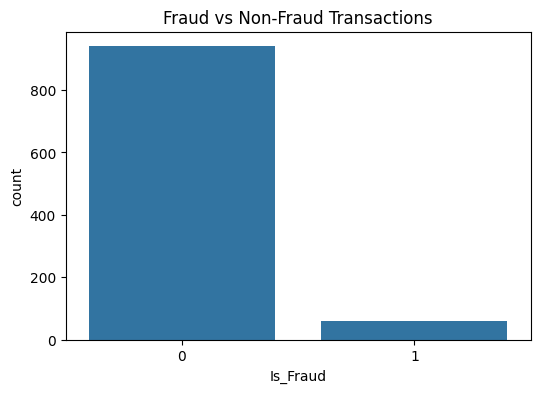

Is_Fraud
0    940
1     60
Name: count, dtype: int64


In [17]:
fraud_counts = df['Is_Fraud'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Is_Fraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

print(fraud_counts)

In [18]:
fraud_percentage = (df['Is_Fraud'].sum() / len(df)) * 100

print("Fraud Percentage:", round(fraud_percentage,2), "%")

Fraud Percentage: 6.0 %


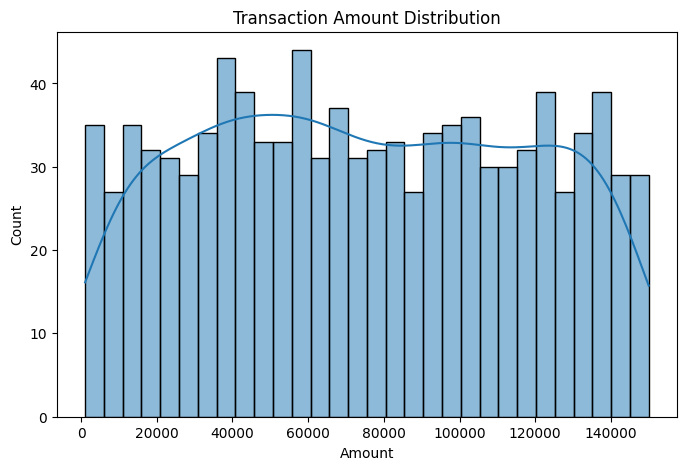

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Transaction_Amount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.show()

Card_Type
Credit Card    75047.627865
Debit Card     74647.880622
Name: Transaction_Amount, dtype: float64


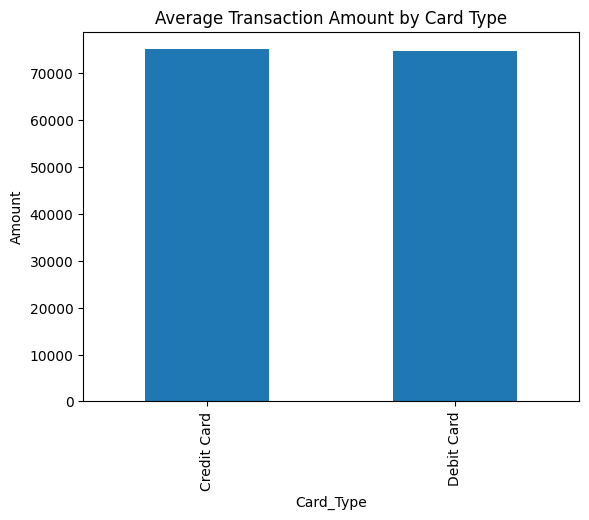

In [21]:
#Average Transaction Amount by Card Type
avg_amount = df.groupby('Card_Type')['Transaction_Amount'].mean()

print(avg_amount)

avg_amount.plot(kind='bar')
plt.title('Average Transaction Amount by Card Type')
plt.ylabel('Amount')
plt.show()

Is_Fraud               0   1
Transaction_Channel         
ATM                  104   6
Online               466  30
POS                  370  24


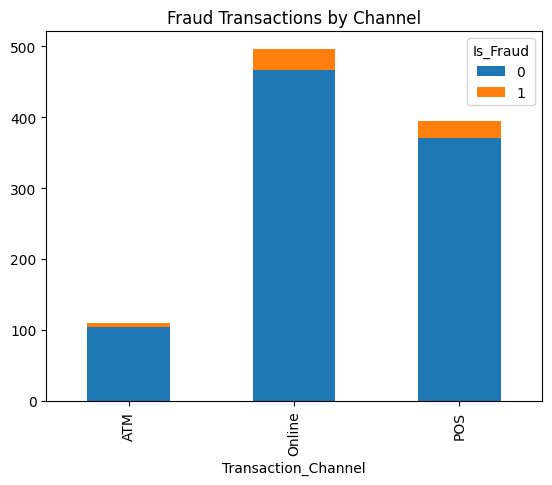

In [22]:
channel_fraud = pd.crosstab(
    df['Transaction_Channel'],
    df['Is_Fraud']
)

print(channel_fraud)

channel_fraud.plot(kind='bar', stacked=True)
plt.title('Fraud Transactions by Channel')
plt.show()

Merchant_Category
Groceries      11
Electronics    10
Education      10
Health          9
Dining          8
Travel          8
Fashion         4
Name: Is_Fraud, dtype: int64


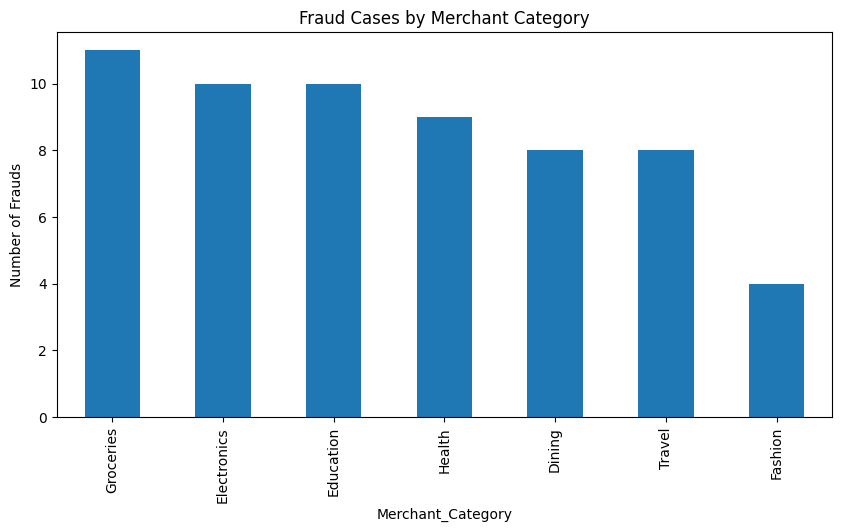

In [23]:
merchant_fraud = df.groupby('Merchant_Category')['Is_Fraud'].sum()

merchant_fraud = merchant_fraud.sort_values(ascending=False)

print(merchant_fraud)

merchant_fraud.plot(kind='bar', figsize=(10,5))
plt.title('Fraud Cases by Merchant Category')
plt.ylabel('Number of Frauds')
plt.show()

Is_Fraud     0   1
Risk_Flag         
High        85  11
Low        658  42
Medium     197   7


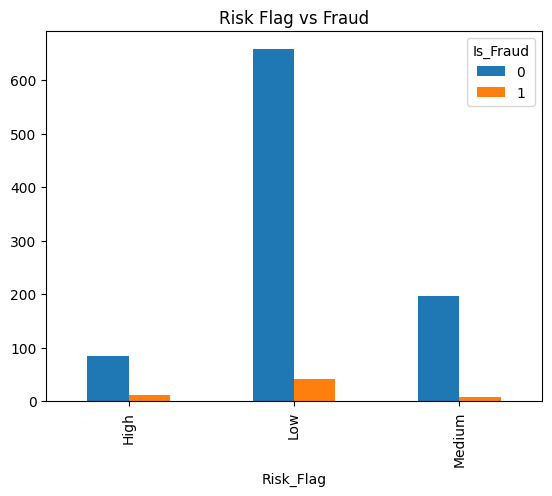

In [24]:
risk_analysis = pd.crosstab(
    df['Risk_Flag'],
    df['Is_Fraud']
)

print(risk_analysis)

risk_analysis.plot(kind='bar')
plt.title('Risk Flag vs Fraud')
plt.show()

City
Jaipur        7
Guwahati      6
Chandigarh    6
Mumbai        5
Pune          5
Hyderabad     4
Kochi         4
Nagpur        4
Ahmedabad     3
Indore        3
Name: count, dtype: int64


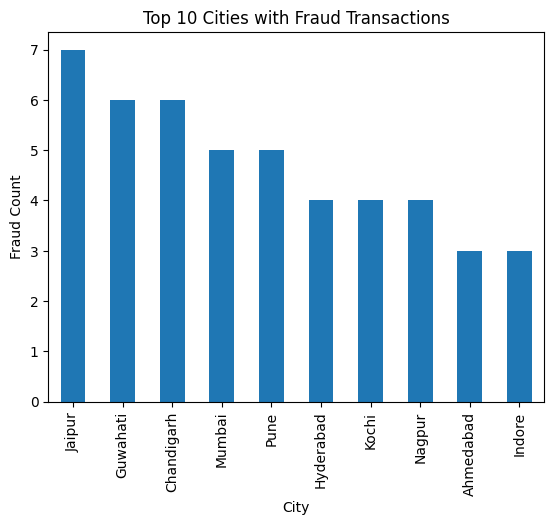

In [26]:
city_fraud = df[df['Is_Fraud']==1]['City'].value_counts().head(10)

print(city_fraud)

city_fraud.plot(kind='bar')
plt.title('Top 10 Cities with Fraud Transactions')
plt.ylabel('Fraud Count')
plt.show()

Month
April         3769805.61
August        5612591.56
December      5195730.15
February      9309479.86
January      11153142.66
July          6262057.37
June          4706146.69
March         5966324.54
May           5276253.24
November      6331510.40
October       5331994.32
September     5946309.25
Name: Transaction_Amount, dtype: float64


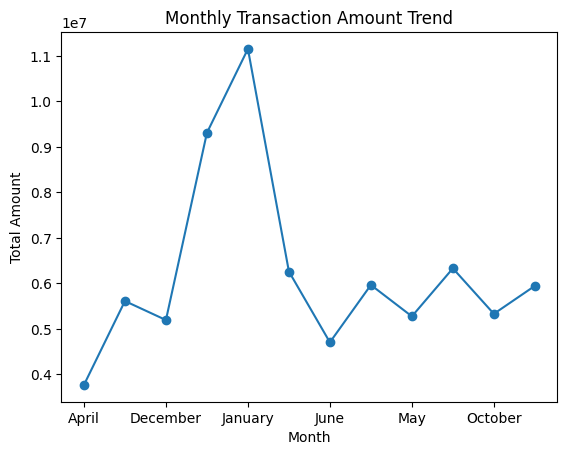

In [27]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

df['Month'] = df['Transaction_Date'].dt.month_name()

monthly_transactions = df.groupby('Month')['Transaction_Amount'].sum()

print(monthly_transactions)

monthly_transactions.plot(kind='line', marker='o')
plt.title('Monthly Transaction Amount Trend')
plt.ylabel('Total Amount')
plt.show()

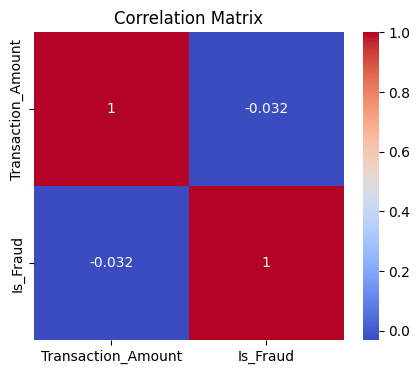

In [30]:
numeric_cols = ['Transaction_Amount', 'Is_Fraud']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

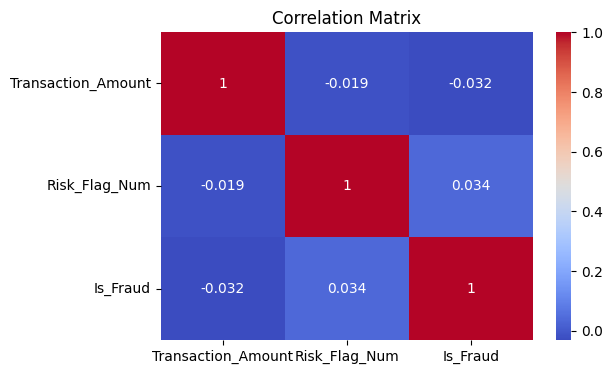

In [31]:
risk_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['Risk_Flag_Num'] = df['Risk_Flag'].map(risk_mapping)

numeric_cols = [
    'Transaction_Amount',
    'Risk_Flag_Num',
    'Is_Fraud'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [32]:
high_risk_fraud = df[
    (df['Risk_Flag'] == 'High') &
    (df['Is_Fraud'] == 1)
]

print("High Risk Fraud Cases:", len(high_risk_fraud))
print(high_risk_fraud.head())

High Risk Fraud Cases: 11
    Transaction_ID   Customer_ID    Card_Type   Masked_Card_Number  \
123  TXN_IND_00124  CUST_IN_2593   Debit Card  **** **** **** 7994   
238  TXN_IND_00239  CUST_IN_4743   Debit Card  **** **** **** 8461   
258  TXN_IND_00259  CUST_IN_4144   Debit Card  **** **** **** 3904   
278  TXN_IND_00279  CUST_IN_4642  Credit Card  **** **** **** 2614   
606  TXN_IND_00607  CUST_IN_2867  Credit Card  **** **** **** 3860   

       Transaction_Date  Transaction_Amount Merchant_Category  \
123 2025-04-14 05:00:00           123563.78         Education   
238 2025-09-27 05:00:00            71678.31       Electronics   
258 2026-01-03 04:00:00            53386.72         Education   
278 2025-10-15 20:00:00            78669.04           Fashion   
606 2025-02-23 14:00:00            87346.16            Health   

    Transaction_Channel       City        State Risk_Flag  Is_Fraud  \
123              Online     Nagpur  Maharashtra      High         1   
238              Onl